# Introduction: Non-singlet UV PDF Neural Network Training

This notebook constructs a physics-informed neural network (PINN) to model parton distribution functions (PDFs) learned from data and DGLAP residuals. To begin, we focus on modeling the non-singlet valence up-quark (UV) PDF at Q^2 = 1.6129, 10, 100, 500, & 1000 from JAM PDF data, the leading-order non-singlet DGLAP equation, and the valence sum rule.

Updates in this notebook:
* The numerical integration scheme is switched from Simpson's Rule to Gaussian-Legendre Quadrature. This switch is intentioned to improve the precision of the network's PDF precision.



# DGLAP Equations Background

The DGLAP (Dokshitzer-Gribov-Lipatov-Altarelli-Parisi) equations handle flavor singlet and non-singlet distributions differently because of gluon coupling.
Here is how the mathematics and physics split between the two categories.
## 1. Non-Singlet Evolution (Decoupled)
Non-singlet distributions describe quantities that carry flavor quantum numbers, such as valence quark distributions ($q_i - \bar{q}_i$) or differences between flavors ($u - d$). [1]

* No Gluon Mixing: Gluons carry no flavor. They cannot directly split into or absorb a specific flavor excess.
* Independent Evolution: Each non-singlet distribution evolves entirely on its own.
* The Equation: It is a single, isolated differential equation:
$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y, Q^2)$$
* Splitting Function: It only requires the quark-to-quark splitting function ($P_{qq}$). [2]

## 2. Singlet Evolution (Coupled Matrix)
The flavor singlet distribution ($\Sigma$) is the sum of all quarks and antiquarks across all active flavors. It represents the total quark density.

* Direct Gluon Mixing: Quarks can radiate gluons, and gluons can split into quark-antiquark pairs. Total quark density and gluon density directly drive each other.
* Matrix Evolution: The equations become a system of two coupled differential equations.
* The Equation: It must be solved simultaneously using a $2 \times 2$ matrix of splitting functions:
$$\frac{d}{d \ln Q^2} \begin{pmatrix} \Sigma(x, Q^2) \\ g(x, Q^2) \end{pmatrix} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} \begin{pmatrix} P_{qq} & 2n_f P_{qg} \\ P_{gq} & P_{gg} \end{pmatrix}\left(\frac{x}{y}\right) \begin{pmatrix} \Sigma(y, Q^2) \\ g(y, Q^2) \end{pmatrix}$$
* Splitting Functions: It requires four functions ($P_{qq}, P_{qg}, P_{gq}, P_{gg}$) and depends on the number of active flavors ($n_f$). [3, 4, 5, 6, 7]

## Key Physical Consequence
As momentum scale ($Q^2$) increases, gluons rapidly split into sea quarks. This causes the singlet distribution to grow explosively at low $x$ values.
In contrast, the non-singlet distribution (like your $u$ valence distribution) does not receive these gluon contributions, causing its total area to remain strictly conserved. [8]





[1] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/1361-6471/ac11c1)
[2] [https://journals.aps.org](https://journals.aps.org/prd/accepted/10.1103/4jvb-24hk)
[3] [https://link.springer.com](https://link.springer.com/article/10.1140/epjc/s10052-026-15417-5)
[4] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/0256-307X/40/9/091201)
[5] [https://link.aps.org](https://link.aps.org/doi/10.1103/2d8y-ljwx)
[6] [https://arxiv.org](https://arxiv.org/html/2604.09534v2)
[7] [https://link.aps.org](https://link.aps.org/doi/10.1103/PhysRevD.110.114011)
[8] [https://www.mdpi.com](https://www.mdpi.com/2571-712X/6/1/15)
[9] [https://ar5iv.labs.arxiv.org](https://ar5iv.labs.arxiv.org/html/1111.5452)



The explicit form of the unpolarized, leading-order (LO) splitting function for flavor non-singlet evolution describes the probability of a quark radiating a gluon and remaining a quark.
## The Explicit Formula
At leading order (one-loop), the non-singlet splitting function $P_{qq}(z)$ is given by:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
## Key Components Explained

* Color Factor ($C_F$): This represents the color charge of a quark in QCD. Its value is exactly $C_F = \frac{4}{3}$.
* Momentum Fraction ($z$): This is the fraction of the parent quark’s longitudinal momentum retained by the daughter quark after radiating the gluon.
* The Plus-Prescription ($+$): The term $\frac{1}{(1-z)_+}$ is a mathematical distribution used to regularize the infrared divergence that occurs when a gluon is emitted with zero energy ($z \to 1$). It is defined via its integration behavior with a test function $f(z)$:
$$\int_0^1 \frac{f(z)}{(1-z)_+} dz = \int_0^1 \frac{f(z) - f(1)}{1-z} dz$$
* Delta Function ($\delta$): The $\frac{3}{2}\delta(1-z)$ term accounts for virtual gluon corrections (loop diagrams) where no physical gluon is emitted, balancing the real emission divergence.

## The Regularized Alternative Form
You will frequently see this written in an alternative, mathematically equivalent form that avoids the plus-prescription by explicitly grouping the virtual and real emission terms:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
When integrated inside the DGLAP equation, it physically simplifies to:
$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$
## Physical Interpretation

* Soft Gluon Divergence: The denominator $(1-z)$ shows that a quark is highly likely to lose a very small amount of momentum to a “soft” gluon.
* Quark Number Conservation: If you integrate $P_{qq}(z)$ from 0 to 1, the result is exactly zero ($\int_0^1 P_{qq}(z)dz = 0$). This mathematical property guarantees that the total number of valence quarks is strictly conserved during QCD evolution, even as the momentum distribution changes shape.








# PINN Model

## Imports & Auxillary Dictionary

Here we import necessary libraries for neural network construction, data interpolation, and plotting. We also set a seed to ensure network training reproducibility.

The auxillary class is used as a dictionary to store variables used to calculate the alpha_s, the strong coupling factor.

In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import zipfile
import copy
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.interpolate import CubicSpline
from mpmath import fp

SEED = 11

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [ ]:
class AUX:

    def __init__(self):

        #--set_constants

        self.CA=3.0
        self.CF=4.0/3.0
        self.TR=0.5
        self.TF=0.5
        self.euler=fp.euler

        #--set_masses

        self.me   = 0.000511
        self.mm   = 0.105658
        self.mt   = 1.77684
        self.mu   = 0.055
        self.md   = 0.055
        self.ms   = 0.2
        self.mc   = 1.28
        self.mb   = 4.18

        self.mZ   = 91.1876
        self.mW   = 80.398
        self.M    = 0.93891897
        self.Mpi  = 0.13803
        self.Mk   = 0.493677
        self.Mdelta = 1.232

        self.me2   = self.me**2
        self.mm2   = self.mm**2
        self.mt2   = self.mt**2
        self.mu2   = self.mu**2
        self.md2   = self.md**2
        self.ms2   = self.ms**2
        self.mc2   = self.mc**2
        self.mb2   = self.mb**2
        self.mZ2   = self.mZ**2
        self.mW2   = self.mW**2
        self.M2    = self.M**2
        self.Mpi2  = self.Mpi**2
        self.Mdelta2=self.Mdelta**2

        #--set_couplings

        self.c2w   = self.mW2/self.mZ2
        self.s2w   = 1.0-self.c2w
        self.s2wMZ = 0.23116
        self.c2wMZ = 1.0 - self.s2wMZ
        self.alfa  = 1/137.036
        self.alphaSMZ = 0.118
        self.GF = 1.1663787e-5   # 1/GeV^2

## Load Data & Define Running Coupling

The PDF data set is sourced from trey24_no_sidis_lo.npy, which contains PDFs at Q^2 = 1.6129, 10, 100, 500, and 1000. At each Q^2 value, there are 200 x points, with 1196 replicas each.

Since this data is set on a hybrid log/linear grid, we interpolate the data onto a purely log-spaced grid, using CubicSpline. This allows us to employ Simpson's Rule, which requires equally spaced quadrature points, to numerically approximate the DGLAP convolution.  

We only interpolate the PDF means and bands for +/- one standard deviation from the mean. This will be used in the Chi-Square loss later on in training.

The running coupling is then defined and used to precompute alpha_s for each Q^2 value, which will be used later to calculate the DGLAP convolution.

In [ ]:

# ── 0. Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/colab_notebooks/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

# Original hybrid grid
X_orig = 10**np.linspace(-4, np.log10(0.4), 100)
X_orig = np.append(X_orig, np.linspace(0.4, 1, 101)[1:])

# upper limit tightened from 0.999 to (1 - 1e-6) for consistency
# with the virtual term domain log(1-x). Both now approach x=1 equally.
N_x = 200
X   = np.logspace(-4, np.log10(1 - 1e-6), N_x)

Q2_vals = [1.6129, 10, 100, 500, 1000]
VAL_Q2  = 500.0
CF = 4.0 / 3.0

#Now interpolate the data for +/- 1 StD. Plot the replica means and StD.

# Interpolate JAM median and +/- 1 Std Dev bands onto the log grid X.
treypdf_log = {}
for q2 in Q2_vals:
    uv_reps        = treypdf[q2]['uv']
    uv_mean_orig   = np.mean(uv_reps, axis=0)
    uv_std_orig    = np.std(uv_reps, axis=0)
    uv_lo_orig     = uv_mean_orig - uv_std_orig     # -1 Std Dev
    uv_hi_orig     = uv_mean_orig + uv_std_orig     # +1 Std Dev

    cs_mean = CubicSpline(X_orig, uv_mean_orig)
    cs_lo  = CubicSpline(X_orig, uv_lo_orig)
    cs_hi  = CubicSpline(X_orig, uv_hi_orig)

    treypdf_log[q2] = {
        'uv'    : cs_mean(X),   # mean on log grid
        'uv_lo' : cs_lo(X),    # -1 Std Dev on log grid
        'uv_hi' : cs_hi(X),    # +1 Std Dev on log grid
    }

print(f'N_x: {N_x} (log-spaced grid: {X.min():.2e} to {X.max():.6f})')

Device: cuda
Mounted at /content/drive
N_x: 200 (log-spaced grid: 1.00e-04 to 0.999999)


Let's visualize the PDF data from trey24_no_sidis.npy. We plot the JAM means and +/- one standard deviation on the original hybrid log/linear grid.

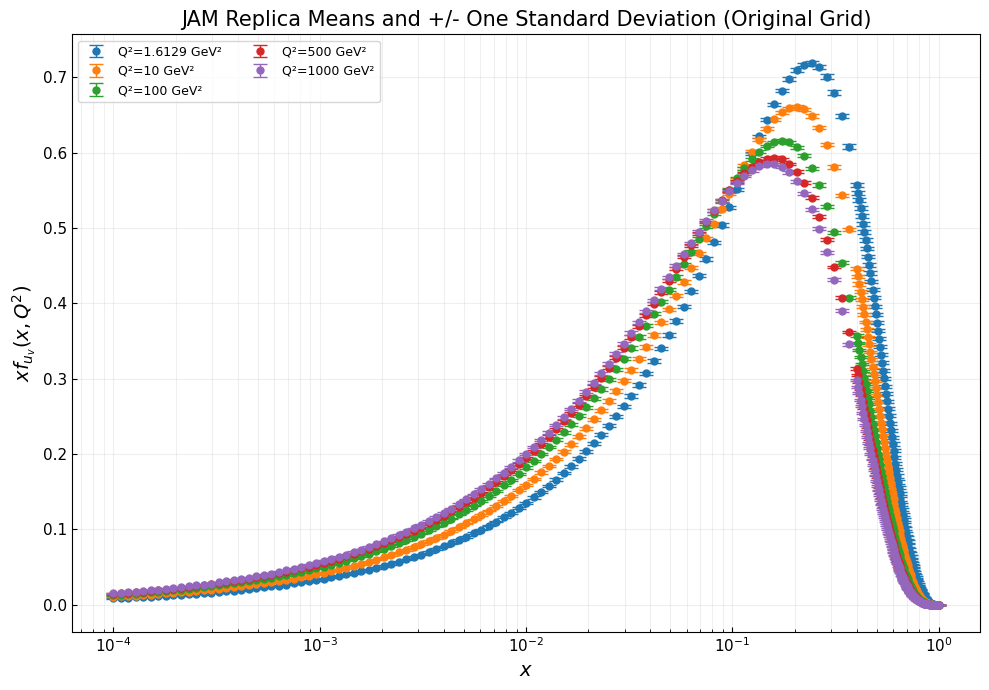

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    uv_reps      = treypdf[q2]['uv']
    uv_mean_orig = np.mean(uv_reps, axis=0)
    uv_std_orig  = np.std(uv_reps, axis=0)

    # Plot mean with error bars representing +/- one standard deviation
    ax.errorbar(X_orig, uv_mean_orig, yerr=uv_std_orig, fmt='o', capsize=5, elinewidth=1.0, markersize = 5, label=f'Q²={q2} GeV²')

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('JAM Replica Means and +/- One Standard Deviation (Original Grid)', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)
ax.legend(fontsize=9, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

Interpolated data: Now we have 1000 x points on the purely log-spaced grid.

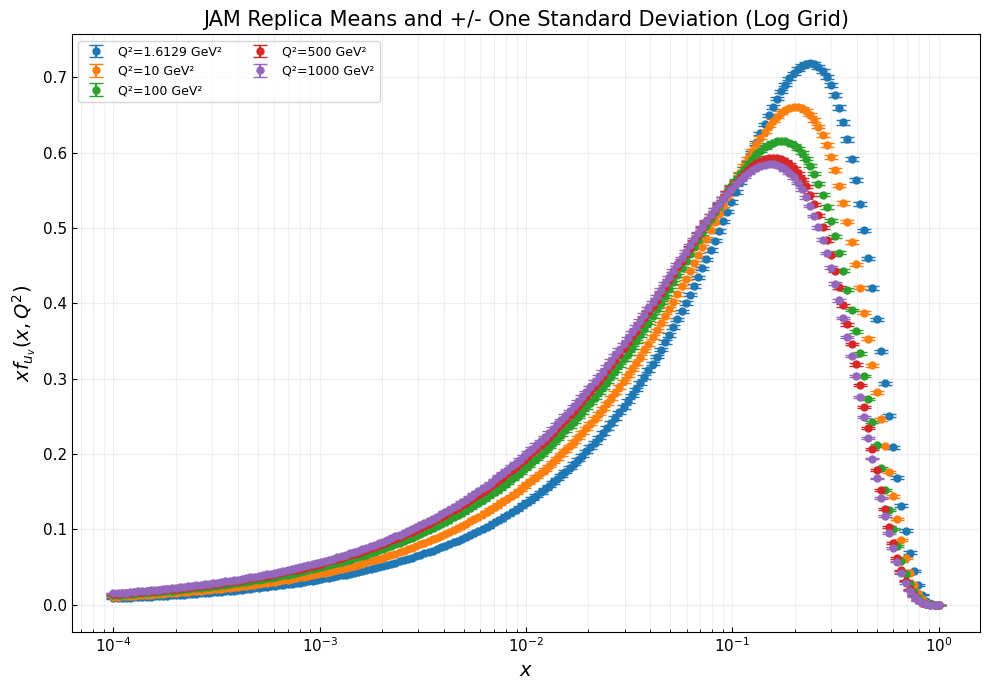

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    # Using the pre-interpolated log-spaced data
    uv_mean_log = treypdf_log[q2]['uv']
    uv_lo_log   = treypdf_log[q2]['uv_lo']
    uv_hi_log   = treypdf_log[q2]['uv_hi']

    # Calculate std dev from the interpolated hi/lo bands
    uv_std_log = (uv_hi_log - uv_lo_log) / 2.0

    # Plot mean with error bars representing +/- one standard deviation
    ax.errorbar(X, uv_mean_log, yerr=uv_std_log, fmt='o', capsize=5, elinewidth=1.5, markersize=5, label=f'Q²={q2} GeV²')

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('JAM Replica Means and +/- One Standard Deviation (Log Grid)', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)
ax.legend(fontsize=9, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
class ALPHAS:

    def __init__(self,order=1):
        """
        order=0: 1-loop
        order=1: 2-loops
        """
        if 'order' in conf: order=conf['order']
        self.order=order
        self.mu20=1
        self.setup()

    def setup(self):
        aux = conf['aux']

        #--setup the beta function
        self.beta=np.zeros((7,3))
        for Nf in range(3,7):
            self.beta[Nf,0]=11.0-2.0/3.0*Nf
            self.beta[Nf,1]=102.-38.0/3.0*Nf
            self.beta[Nf,2]=2857.0/2.0-5033.0/18.0*Nf+325.0/54.0*Nf**2

        # uses alphaS(mZ)--> backwards evolution
        self.aZ  = conf['aux'].alphaSMZ/(4*np.pi)
        self.ab=self.evolve_a(self.aZ,aux.mZ2,aux.mb2,5)
        self.ac=self.evolve_a(self.ab,aux.mb2,aux.mc2,4)
        self.a0=self.evolve_a(self.ac,aux.mc2,self.mu20,3)

        # we will store all Q2 values of alphaS
        self.storage={}


    def get_Nf(self,mu2):
        aux = conf['aux']
        Nf=3
        if mu2>=(aux.mc2): Nf+=1
        if mu2>=(aux.mb2): Nf+=1
        return Nf

    def beta_func(self,a,Nf):
        betaf = -self.beta[Nf,0]
        if self.order>=1: betaf+=-a*self.beta[Nf,1]
        if self.order>=2: betaf+=-a*self.beta[Nf,2]
        return betaf*a**2

    def evolve_a(self,a0,mu20,mu2,Nf):
        # Runge-Kutta implemented in pegasus
        LR = np.log(mu2/mu20)/20.0
        a=a0
        for k in range(20):
            XK0 = LR * self.beta_func(a,Nf)
            XK1 = LR * self.beta_func(a + 0.5 * XK0,Nf)
            XK2 = LR * self.beta_func(a + 0.5 * XK1,Nf)
            XK3 = LR * self.beta_func(a + XK2,Nf)
            a+= (XK0 + 2.* XK1 + 2.* XK2 + XK3) * 0.166666666666666
        return a

    def get_a(self,mu2):
        aux = conf['aux']

        if mu2 not in self.storage:

            if aux.mb2<=mu2:
                mu20,a0,Nf=aux.mb2,self.ab,5
            elif aux.mc2<=mu2 and mu2<aux.mb2:
                mu20,a0,Nf=aux.mc2,self.ac,4
            elif mu2<aux.mc2:
                mu20,a0,Nf=self.mu20,self.a0,3
            self.storage[mu2]=self.evolve_a(a0,mu20,mu2,Nf)

        return self.storage[mu2]

    def get_alphaS(self,mu2):
        return self.get_a(mu2)*4*np.pi

conf = {}
conf['aux']   = AUX()
conf['order'] = 0    # LO running: one-loop beta function, consistent with LO splitting function
mu2=conf['aux'].mZ2

alphas_runner = ALPHAS()


In [ ]:
# Precompute running alpha_s for all training Q² values.
# get_alphaS returns a Python float; convert to float32 scalar tensor
# for use inside dglap_convolution which operates in torch.
alphas_Q2 = {
    q2: torch.tensor(alphas_runner.get_alphaS(q2), dtype=torch.float32, device=device)
    for q2 in Q2_vals
}

print('Running alpha_s values:')
for q2, a in alphas_Q2.items():
    print(f'  Q² = {q2:>8.4f} GeV²  →  alpha_s = {a.item():.6f}')

Running alpha_s values:
  Q² =   1.6129 GeV²  →  alpha_s = 0.319246
  Q² =  10.0000 GeV²  →  alpha_s = 0.230247
  Q² = 100.0000 GeV²  →  alpha_s = 0.173084
  Q² = 500.0000 GeV²  →  alpha_s = 0.147941
  Q² = 1000.0000 GeV²  →  alpha_s = 0.139230


## Build Training/Validation Tensors & Define Collocation Points

The training and valiation tensors are then constructed using the interpolated data. The neural network target will be the JAM UV means at Q^2=1.6129, 10, 100, 500, and 1000, which serve as the boundary conditions to guide the network in the PDF's kinematic dependence.

The network input is (x, ln(x), ln(Q^2)), and the output is xf(x, Q^2).

PDF data at Q^2=500 is used to build a validation tensor, which will indicate the network's ability to generalize to unseen data.

The collocation grid includes all x data points. This grid defines (x, Q^2) points where the DGLAP covolution will be evaluated.

In [ ]:
# ── 2. Build train / val tensors using interpolated data ───────────────────
log_x = np.log(X)

train_inp, train_tgt, train_std = [], [], []
val_inp,   val_tgt,   val_std   = [], [], []

# Define the Q^2 values to use for data training
DATA_TRAIN_Q2_VALS = [1.6129, 10, 100, 1000]

for q2 in Q2_vals:
    uv_mean = treypdf_log[q2]['uv']
    uv_std  = (treypdf_log[q2]['uv_hi'] - treypdf_log[q2]['uv_lo']) / 2.0 # Standard deviation from +/- 1 Std Dev band
    log_q2    = np.full(N_x, np.log(q2))
    inp       = np.stack([X, log_x, log_q2], axis=1) # Stack X, ln(X), and ln(Q^2) as input features
    tgt       = uv_mean[:, None]
    std       = uv_std[:, None]

    if q2 in DATA_TRAIN_Q2_VALS:
        train_inp.append(inp)
        train_tgt.append(tgt)
        train_std.append(std)
    elif q2 == VAL_Q2:
        val_inp.append(inp)
        val_tgt.append(tgt)
        val_std.append(std)

train_X   = torch.tensor(np.concatenate(train_inp), dtype=torch.float32).to(device)
train_Y   = torch.tensor(np.concatenate(train_tgt), dtype=torch.float32).to(device)
train_STD = torch.tensor(np.concatenate(train_std), dtype=torch.float32).to(device)
val_X     = torch.tensor(np.concatenate(val_inp),   dtype=torch.float32).to(device)
val_Y     = torch.tensor(np.concatenate(val_tgt),   dtype=torch.float32).to(device)
val_STD   = torch.tensor(np.concatenate(val_std),   dtype=torch.float32).to(device)

print(f'train_X: {train_X.shape}  val_X: {val_X.shape}')

train_X: torch.Size([800, 3])  val_X: torch.Size([200, 3])


In [ ]:
# ── 3. Collocation points ────────────────────────────────────────────────────
#
#  Reuse the training Q² values and the same x grid.
#  VAL_Q2=500 is explicitly excluded so the validation Q² receives
#  no physics-based gradient signal during training.

colloc_inp_list = []

for q2 in Q2_vals:
    if q2 == VAL_Q2:
        continue
    log_q2_col = np.full(N_x, np.log(q2))
    inp        = np.stack([X, log_x, log_q2_col], axis=1)   # (N_x, 3) # Stack X, ln(X), and ln(Q^2) for collocation input
    colloc_inp_list.append(inp)

# Shape: (N_train_Q2 * N_x, 3)  — 4 Q² values × 1000 x points = 4000 rows
# FIX (issue 4): updated from 200 x points / 800 rows; grid is now N_x=1000
colloc_np = np.concatenate(colloc_inp_list)
colloc_X  = torch.tensor(colloc_np, dtype=torch.float32).to(device)

# x_grid as a tensor — needed for Simpson convolution
x_grid_t  = torch.tensor(X, dtype=torch.float32).to(device)

print(f'Collocation grid: {colloc_X.shape}')

Collocation grid: torch.Size([800, 3])


## Define Weights for Gauss-Lengendre Quadrature

Next, we define quadrature weights to numerically approximate the DGLAP convolution integral with Gauss-Legendre Quadrature. We use the Numpy legendre.leggauss function to generate the nodes and weights for n = 16.

Additionally, we define Simpson's Rule weights for the Sum Rule integral.



In [ ]:

# ── Gauss-Legendre nodes and weights (for DGLAP convolution) ────────────────
from numpy.polynomial.legendre import leggauss

N_GL = 64
gl_nodes_np, gl_weights_np = leggauss(N_GL)
gl_nodes   = torch.tensor(gl_nodes_np,   dtype=torch.float32, device=device)
gl_weights = torch.tensor(gl_weights_np, dtype=torch.float32, device=device)
print(f'GL nodes: {gl_nodes.shape}, GL weights sum={gl_weights.sum().item():.6f} (should = 2.0)')

Simpson weights sum=9.210340 (should ≈ 9.210339)
GL nodes: torch.Size([64]), GL weights sum=2.000000 (should = 2.0)


In [ ]:
# ── Uniform Simpson weights (log-space integration) ───────────────────────

def build_log_simpson_weights(N, delta_lnx):
    """
    Composite Simpson weights for a uniform grid in ln(y) space.

    Integration variable: t = ln(y), uniform spacing delta_lnx in log space.
    Composite Simpson pattern for N points:
    [1, 4, 2, 4, 2, ..., 4, 2, 4, 1] × (delta_lnx / 3)
    For even N (N=200), N-1=199 points cover an even number of intervals (198).
    The last interval [N-2, N-1] uses the trapezoid fallback.

    The trapezoid then adds delta_lnx/2 to both w[N-2] and w[N-1],
    so w[N-2] correctly accumulates Simpson (delta_lnx/3) + trap (delta_lnx/2).
    """
    w = torch.zeros(N)

    # ── Composite Simpson over first N-1 points (indices 0 to N-2) ───────
    w[0]       = 1.0          # left endpoint
    w[1:N-2:2] = 4.0          # odd interior indices (midpoints of each pair)
    w[2:N-2:2] = 2.0          # even interior indices (shared endpoints)
    w[N-2]     = 1.0          # right endpoint
    w = w * (delta_lnx / 3.0)

    # ── Trapezoid fallback for final interval [N-2, N-1] ─────────────────
    w[N-2] += delta_lnx / 2.0
    w[N-1]  = delta_lnx / 2.0  # right endpoint

    return w

# assert log spacing is truly uniform before using uniform-h formula
log_X     = np.log(X)
spacings  = np.diff(log_X)
assert np.allclose(spacings, spacings[0], rtol=1e-6), \
    'Grid is not uniform in log space — switch to non-uniform weights'
delta_lnx = float(spacings[0])

simp_weights = build_log_simpson_weights(N_x, delta_lnx).to(device)

print(f'delta_lnx:            {delta_lnx:.8f}')
print(f'Weights sum:          {simp_weights.sum().item():.6f}')
print(f'Expected (ln range):  {log_X[-1] - log_X[0]:.6f}')


delta_lnx:            0.00921956
Weights sum:          9.210340
Expected (ln range):  9.210339


## NS Splitting Function and DGLAP Convolution

Previously we defined the LO non-singlet splitting function $P_{qq}(z)$ as:

$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$


We then examined a regularized alternative form
:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$

Which, when integrated inside the DGLAP equation, becomes:

$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$

Below, we define the LO NS splitting function for the real-emission term. In the denominator, we add an epsilon term of $\frac{\Delta ln(x)}{2}$ to prevent numerical near-division-by-zero when z is very close to 1.

In [ ]:
# ── 5. LO non-singlet splitting function ─────────────────────────────────────

def P_qq_kernel(z):
    """
    Real-emission part of LO P_qq: (1 + z²) / (1 - z).
    C_F applied in dglap_convolution.
    Singularity at z=1 regulated by [f(y)-z*f(x)] subtraction.
    z : tensor, any shape, values in (0, 1)
    """
    # FIX (issue 3): the old guard used a Simpson grid spacing variable.
    # GL nodes never sit at z=1 exactly; a small epsilon suffices.
    return (1 + z**2) / (1 - z + 1e-12)

Now, we define a function to numerically approximate the RHS of the NS DGLAP equation at LO (after taking $ t = ln(y)$ ):

$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} C_F
\left[
    \int_{\ln x}^{0}
    \frac{1 + \left(\frac{x}{e^t}\right)^2}{1 - \frac{x}{e^t}}
    \left[ f(e^t) - \frac{x}{e^t}\, f(x) \right] dt
    + \left( \frac{3}{2} + 2\ln(1-x) \right) f(x)
\right]$$

The implemented plus-prescription handles the singularity at $z=1$ by calculating $[f(y) - z \cdot f(x)]$. When $y \to x$ (which means $z \to 1$), the term $(f_y - z f_x)$ goes to zero at the exact same rate as the denominator in the splitting function $(1-z)$. This cancels the infinity, making the result finite and numerically stable.

The kernel, $P_{qq}(z) (f_y- z f_x)$, is then evaluated numerically at Gauss-Legendre nodes, using the previously defined quadrature weights.

The plus-prescription math leaves behind a virtual emission term involving the integral of the splitting function from 0 to 1. This term accounts for the probability that a quark does not radiate. It depends on $\ln(1-x)$ and the constant $3/2$.

In [ ]:
def dglap_convolution_gl(xf_fn, x_grid, gl_nodes, gl_weights, alpha_s):
    """
    xf_fn    : callable — takes a tensor of x values, returns xf(x).
                In practice this is a partial application of model(inp)
                for a fixed Q², but the model must be called at the GL nodes.
    x_grid   : (N_x,) query points — the x values we want the RHS at
    gl_nodes : (N_GL,) Gauss-Legendre nodes on [-1, 1]
    gl_weights: (N_GL,) corresponding weights
    alpha_s  : scalar tensor
    """
    N_x  = x_grid.shape[0]
    N_GL = gl_nodes.shape[0]
    ln_xi = torch.log(x_grid)           # (N_x,)   ln(x_i) — negative values

    # ── Map GL nodes to [ln(x_i), 0] for every query point ──────────────────
    # t_nodes[i, j] = GL node j mapped to the integration domain of query i
    # shape: (N_x, N_GL)
    half_range = -ln_xi / 2.0           # (N_x,)   = |ln(x_i)| / 2
    t_mid      = ln_xi / 2.0            # (N_x,)   midpoint of [ln(x_i), 0]

    t_nodes = t_mid.unsqueeze(1) + half_range.unsqueeze(1) * gl_nodes.unsqueeze(0)
    # t_nodes[i, j] = ln(x_i)/2 * (1 - xi_j), shape: (N_x, N_GL)

    y_nodes = torch.exp(t_nodes)        # (N_x, N_GL)  y = e^t for each node

    # ── Evaluate the PDF at the GL nodes ────────────────────────────────────
    # This is the key difference from Simpson: we need f at arbitrary y values,
    # not just the fixed x-grid. xf_fn must accept a flat tensor and return xf.
    y_flat    = y_nodes.reshape(-1)     # (N_x * N_GL,)
    xf_y_flat = xf_fn(y_flat)          # (N_x * N_GL,)
    xf_y      = xf_y_flat.reshape(N_x, N_GL)   # (N_x, N_GL)
    f_y       = xf_y / y_nodes         # f(y) = xf(y)/y

    # ── Plus-prescription subtraction ────────────────────────────────────────
    # FIX (issue 4): cache xf_fn(x_grid) to avoid a second identical
    # forward pass in the virtual term below.
    xf_at_x = xf_fn(x_grid)                              # single cached call
    f_x     = (xf_at_x / x_grid).unsqueeze(1)            # (N_x, 1)
    z   = x_grid.unsqueeze(1) / y_nodes            # (N_x, N_GL)

    kernel    = (1 + z**2) / (1 - z + 1e-12)       # (N_x, N_GL)  P(z)
    integrand = kernel * (f_y - z * f_x)            # (N_x, N_GL)

    # ── Weighted sum with Jacobian ────────────────────────────────────────────
    # Jacobian = half_range = |ln(x_i)| / 2, shape (N_x,)
    jacobian   = half_range.unsqueeze(1)            # (N_x, 1)
    real_term  = (jacobian * (integrand * gl_weights.unsqueeze(0))).sum(dim=1)

    # ── Virtual correction ────────────────────────────────────────────────────
    log_1mx  = torch.log(1.0 - x_grid + 1e-12)
    f_x_diag = xf_at_x / x_grid   # FIX (issue 4): reuse cached result
    virtual  = (1.5 + 2.0 * log_1mx) * f_x_diag

    prefactor = alpha_s / (2 * torch.pi)
    return prefactor * CF * (real_term + virtual)

Now we define the make_xf_fn, which will evaluate the model at the given GL nodes. This is done on a different grid than training since we need to evaluate the PDF at the specific GL nodes.

In [ ]:
def make_xf_fn(model, q2, device):
    """Return a callable xf(x) at fixed Q², evaluating the network."""
    log_q2 = np.log(q2)
    def xf_fn(x_vals):
        # x_vals: (N,) tensor of x values (the GL nodes for this query)
        N       = x_vals.shape[0]
        log_x_v = torch.log(x_vals)
        log_q2_v = torch.full((N,), log_q2, device=device, dtype=torch.float32)
        inp      = torch.stack([x_vals, log_x_v, log_q2_v], dim=1)
        return model(inp).squeeze()
    return xf_fn

## Define Neural Network & Training Loop

Now we finally define the neural network, which takes $(x, ln(x), ln(Q^2))$  and outputs $x f_{uv}(x, Q^2)$. The positivity of the output PDF prediction (for LO PDFs) is enforced by a final Softplus layer. Currently, hyperbolic tanget activation functions are used.



In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3,  32), nn.Tanh(), # Input layer: 3 features (X, ln(X), ln(Q^2))
            nn.Linear(32, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32,  1), nn.Softplus()
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

    def chi_square_loss(self, pred, jam_mean, jam_std):
        # Calculate ((NN output - JAM mean) / (one standard deviation))^2
        # Add a small epsilon to jam_std to prevent division by zero
        epsilon = 1e-6
        return torch.mean(((pred - jam_mean) / (jam_std + epsilon))**2)

    def relative_absolute_error(self, pred, jam_mean):
        # Calculate ((NN output - JAM mean) / (JAM mean))
        epsilon = 1e-6
        return torch.mean(torch.abs((pred - jam_mean) / (jam_mean + epsilon)))

model = PINN().to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters())}')

PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=32, bias=True)
    (11): Tanh()
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Softplus(beta=1.0, threshold=20.0)
  )
)
Parameters: 16833


We employ data batching to diversify training data per epoch, with a batch size of 128 and 8 batches/epoch. The Adam optimizer and ReduceLROnPlateau learning rate scheduler are used. The early stop patience has been decreased to prevent overfitting. Previously, this hyperparameter was too high (2000).

In [ ]:
# ── 8. Training hyperparameters ───────────────────────────────────────────────

BATCH_SIZE          = 128
N_EPOCHS            = 30000 #was 60,000
LOG_EVERY           = 1000
EARLY_STOP_PATIENCE = 1000
LAMBDA_DGLAP        = 50
LAMBDA_SR           = 500
LAMBDA_DATA         = 5

N_TRAIN             = train_X.shape[0]

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=200, min_lr=1e-6
)

Finally, the training loop. Structure per epoch:
* (a) Data loss: mini-batch forward passes, weighted accumulation
* (b) Compute DGLAP residual once on full collocation grid (never batched)     
* (c) Form total loss, single backward + optimizer step

In [ ]:
import torch.nn.functional as F

train_losses, val_losses         = [], []
data_losses_log, phys_losses_log = [], []
sr_losses_log = [] # Initialize new list for sum rule losses
train_rae_log = [] # New list for training relative absolute error
val_rae_log   = [] # New list for validation relative absolute error
best_val_loss = float('inf')
best_val_rae  = float('inf') # Initialize best_val_rae
best_state    = None
no_improve    = 0
t0 = time.time()

train_Q2_vals = [q2 for q2 in Q2_vals if q2 != VAL_Q2]

print(f'Training samples    : {N_TRAIN}')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Batches/epoch       : {(N_TRAIN + BATCH_SIZE - 1) // BATCH_SIZE}')
print(f'Early stop patience : {EARLY_STOP_PATIENCE}')
# FIX (issue 5): added lambda values — critical for interpreting training output
print(f'Lambda Data         : {LAMBDA_DATA}')
print(f'Lambda DGLAP        : {LAMBDA_DGLAP}')
print(f'Lambda SR           : {LAMBDA_SR}')
print(f'DGLAP Q2 values     : {train_Q2_vals}')
print('Starting...')

for epoch in range(1, N_EPOCHS + 1):

    model.train()
    optimizer.zero_grad()

    # __ (a) Data loss: mini-batch accumulation ____________________________
    perm      = torch.randperm(N_TRAIN, device=device)
    batch_chi_sq_losses = [] # Accumulate individual batch chi_square losses

    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx       = perm[start : start + BATCH_SIZE]
        xb        = train_X[idx]
        yb        = train_Y[idx]
        stdb      = train_STD[idx]
        pred_b    = model(xb)
        batch_chi_sq_losses.append(model.chi_square_loss(pred_b, yb, stdb) * len(idx)) # Use chi_square_loss
    data_loss = torch.sum(torch.stack(batch_chi_sq_losses)) / N_TRAIN # Sum up and average

    # __ (b) DGLAP residual: computed once on full collocation grid ________
    x_col     = colloc_X[:, 0:1] # X
    ln_x_col  = colloc_X[:, 1:2] # ln(X)
    ln_q2_col = colloc_X[:, 2:3].clone().detach().requires_grad_(True) # ln(Q^2)
    colloc_inp = torch.cat([x_col, ln_x_col, ln_q2_col], dim=1)

    xf_colloc = model(colloc_inp)

    dxf_dlnq2 = torch.autograd.grad(
        outputs      = xf_colloc,
        inputs       = ln_q2_col,
        grad_outputs = torch.ones_like(xf_colloc),
        create_graph = True,
    )[0]

    dglap_residuals = []
    sr_integrals_for_logging = {} # New dictionary to store integrals for logging
    sr_residuals = [] # New list for sum rule residuals

    for q2 in train_Q2_vals:

        # FIX (issue 1): boolean Q² mask selects the N_x rows for this Q²
        # from the full collocation tensor. The old code used ln_q2_col
        # (a float tensor) as an index, which is invalid in PyTorch.
        log_q2_val = np.log(q2)
        q2_mask    = (colloc_X[:, 2] - log_q2_val).abs() < 1e-4

        xf_q2  = xf_colloc[q2_mask].squeeze()    # (N_x,)
        dxf_q2 = dxf_dlnq2[q2_mask].squeeze()    # (N_x,)

        xf_fn_q2 = make_xf_fn(model, q2, device)
        rhs      = dglap_convolution_gl(xf_fn_q2, x_grid_t, gl_nodes, gl_weights, alphas_Q2[q2])
        dglap_residuals.append(dxf_q2 - rhs)

        # FIX (issue 2): sum rule uses log-space Simpson weights, not GL.
        # ∫uv dx = Σ xf_i · w_i^ln  (x factors cancel in log-space).
        # xf_colloc was not callable; gl_weights wrong domain — both fixed.
        integral_val = (xf_q2 * simp_weights).sum()
        sr_integrals_for_logging[q2] = integral_val.item()

        sr_residuals.append(integral_val - 2.0)

    phys_loss = torch.mean(torch.cat(dglap_residuals)**2)
    sr_loss   = torch.mean(torch.stack(sr_residuals)**2) # Calculate SR loss

    # __ (d) Total loss calculation _________________
    total_loss = LAMBDA_DATA * data_loss + LAMBDA_DGLAP * phys_loss + LAMBDA_SR * sr_loss

    data_grad_norm = 0.0
    phys_grad_norm = 0.0
    sr_grad_norm = 0.0

    if epoch % LOG_EVERY == 0:
        # Compute gradient norms from each loss term separately using torch.autograd.grad
        # This avoids interfering with the main backward pass graph traversal by total_loss.backward()

        # Data Loss gradient norm
        data_grads = torch.autograd.grad(LAMBDA_DATA * data_loss, model.parameters(), retain_graph=True, allow_unused=True)
        data_grad_norm = sum(g.norm()**2 for g in data_grads if g is not None).sqrt().item()

        # DGLAP Loss gradient norm
        phys_grads = torch.autograd.grad(LAMBDA_DGLAP * phys_loss, model.parameters(), retain_graph=True, allow_unused=True)
        phys_grad_norm = sum(g.norm()**2 for g in phys_grads if g is not None).sqrt().item()

        # Sum Rule Loss gradient norm
        # retain_graph=True is needed here to keep the graph for total_loss.backward()
        sr_grads = torch.autograd.grad(LAMBDA_SR * sr_loss, model.parameters(), retain_graph=True, allow_unused=True)
        sr_grad_norm = sum(g.norm()**2 for g in sr_grads if g is not None).sqrt().item()

    # __ (e) Actual backward pass for total_loss and optimizer step _________________
    total_loss.backward()
    optimizer.step()

    # __ Epoch bookkeeping _________________________________________________
    train_loss = total_loss.item()
    phys_loss_val = phys_loss.item()
    sr_loss_val = sr_loss.item()

    model.eval()
    with torch.no_grad():
        val_pred = model(val_X)
        val_loss = model.chi_square_loss(val_pred, val_Y, val_STD).item()
        val_rae  = model.relative_absolute_error(val_pred, val_Y).item() # Calculate validation RAE

        train_pred = model(train_X) # Get prediction for full training set
        train_rae  = model.relative_absolute_error(train_pred, train_Y).item() # Calculate training RAE

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    data_losses_log.append(data_loss.item())
    phys_losses_log.append(phys_loss_val)
    sr_losses_log.append(sr_loss_val)
    train_rae_log.append(train_rae)
    val_rae_log.append(val_rae)

    scheduler.step(val_rae) # Use val_rae for learning rate scheduling

    if val_rae < best_val_rae: # Use val_rae for early stopping
        best_val_rae  = val_rae
        best_val_loss = val_loss  # FIX (issue 1): keep chi-square in sync so
                                  # the checkpoint and final print are not inf
        best_state    = copy.deepcopy(model.state_dict())
        no_improve    = 0
    else:
        no_improve   += 1

    if epoch % LOG_EVERY == 0:
        elapsed   = time.time() - t0
        remaining = elapsed / epoch * (N_EPOCHS - epoch)
        lr        = optimizer.param_groups[0]['lr']
        ratio_dglap_data = phys_loss_val / (data_loss.item() + 1e-12)
        ratio_sr_data = sr_loss_val / (data_loss.item() + 1e-12)

        with torch.no_grad():
            for q2 in train_Q2_vals:
                integral = sr_integrals_for_logging[q2]
                print(f'  Sum rule at Q²={q2:>8.4f}: ∫uv dx = {integral:.4f}  ' \
                      f'(target 2.0, dev {integral-2.0:+.4f})')
        print(f'Epoch {epoch:>5}/{N_EPOCHS} | '
              f'Data: {data_loss.item():.2e} | '
              f'DGLAP: {phys_loss_val:.2e} | '
              f'SR: {sr_loss_val:.2e} | '
              f'DGLAP/Data: {ratio_dglap_data:.2e} | '
              f'SR/Data: {ratio_sr_data:.2e} | '
              f'Val: {val_loss:.2e} | '
              f'Train RAE: {train_rae:.2e} | '
              f'Val RAE: {val_rae:.2e} | '
              f'LR: {lr:.1e} | '
              f'No improve: {no_improve} | '
              f'ETA: {remaining/60:.1f}m')
        print(f'Epoch {epoch:>5} | '
              f'Data grad norm: {data_grad_norm:.2e} | '
              f'DGLAP grad norm: {phys_grad_norm:.2e} | '
              f'SR grad norm: {sr_grad_norm:.2e} | '
              f'DGLAP grad ratio: {phys_grad_norm/(data_grad_norm+1e-12):.2e} | '
              f'SR grad ratio: {sr_grad_norm/(data_grad_norm+1e-12):.2e}')

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

model.load_state_dict(best_state)
# FIX (issue 1): report both RAE and chi-square; best_val_loss is now
# correctly updated each time best_val_rae improves (see block above)
print(f'\nDone. Best val RAE: {best_val_rae*100:.4f}%  |  Best val chi²: {best_val_loss:.4e}')

Training samples    : 800
Batch size          : 128
Batches/epoch       : 7
Early stop patience : 1000
Lambda Data         : 5
Lambda DGLAP        : 50
Lambda SR           : 500
DGLAP Q2 values     : [1.6129, 10, 100, 1000]
Starting...
  Sum rule at Q²=  1.6129: ∫uv dx = 0.7792  (target 2.0, dev -1.2208)
  Sum rule at Q²= 10.0000: ∫uv dx = 0.2102  (target 2.0, dev -1.7898)
  Sum rule at Q²=100.0000: ∫uv dx = 0.1184  (target 2.0, dev -1.8816)
  Sum rule at Q²=1000.0000: ∫uv dx = 0.0778  (target 2.0, dev -1.9222)
Epoch  1000/30000 | Data: 3.55e+04 | DGLAP: 4.91e+01 | SR: 2.98e+00 | DGLAP/Data: 1.39e-03 | SR/Data: 8.41e-05 | Val: 4.28e+04 | Train RAE: 8.01e+00 | Val RAE: 1.09e+01 | LR: 1.0e-03 | No improve: 0 | ETA: 18.3m
Epoch  1000 | Data grad norm: 8.91e+05 | DGLAP grad norm: 8.89e+04 | SR grad norm: 7.17e+03 | DGLAP grad ratio: 9.98e-02 | SR grad ratio: 8.05e-03
  Sum rule at Q²=  1.6129: ∫uv dx = 1.9217  (target 2.0, dev -0.0783)
  Sum rule at Q²= 10.0000: ∫uv dx = 0.5497  (target 2.

## Plot Training/Validation Loss & Model's PDF Prediction

Let's plot the results of the network training. The training loss represents the total loss:

$\text{total loss} = \lambda_{\text{Data}} \cdot L_{\text{Data}} + \lambda_{\text{DGLAP}} \cdot L_{\text{DGLAP}} + \lambda_{\text{Sum Rule}} \cdot L_{\text{Sum Rule}}$



where $L_{Data}$ is calculated with Chi-Square and $L_{DGLAP}$ & $L_{Sum Rule}$ is calculated with MSE, where Chi-Square is

$$\left(\frac{ \text{ NN Output}\ - f_{uv \text{ JAM mean}}}{\sigma_{uv}}\right)^2$$

The validation loss represents the Chi-Square between the model PDF predictions and the JAM mean PDFs at $Q^2 = 500$.

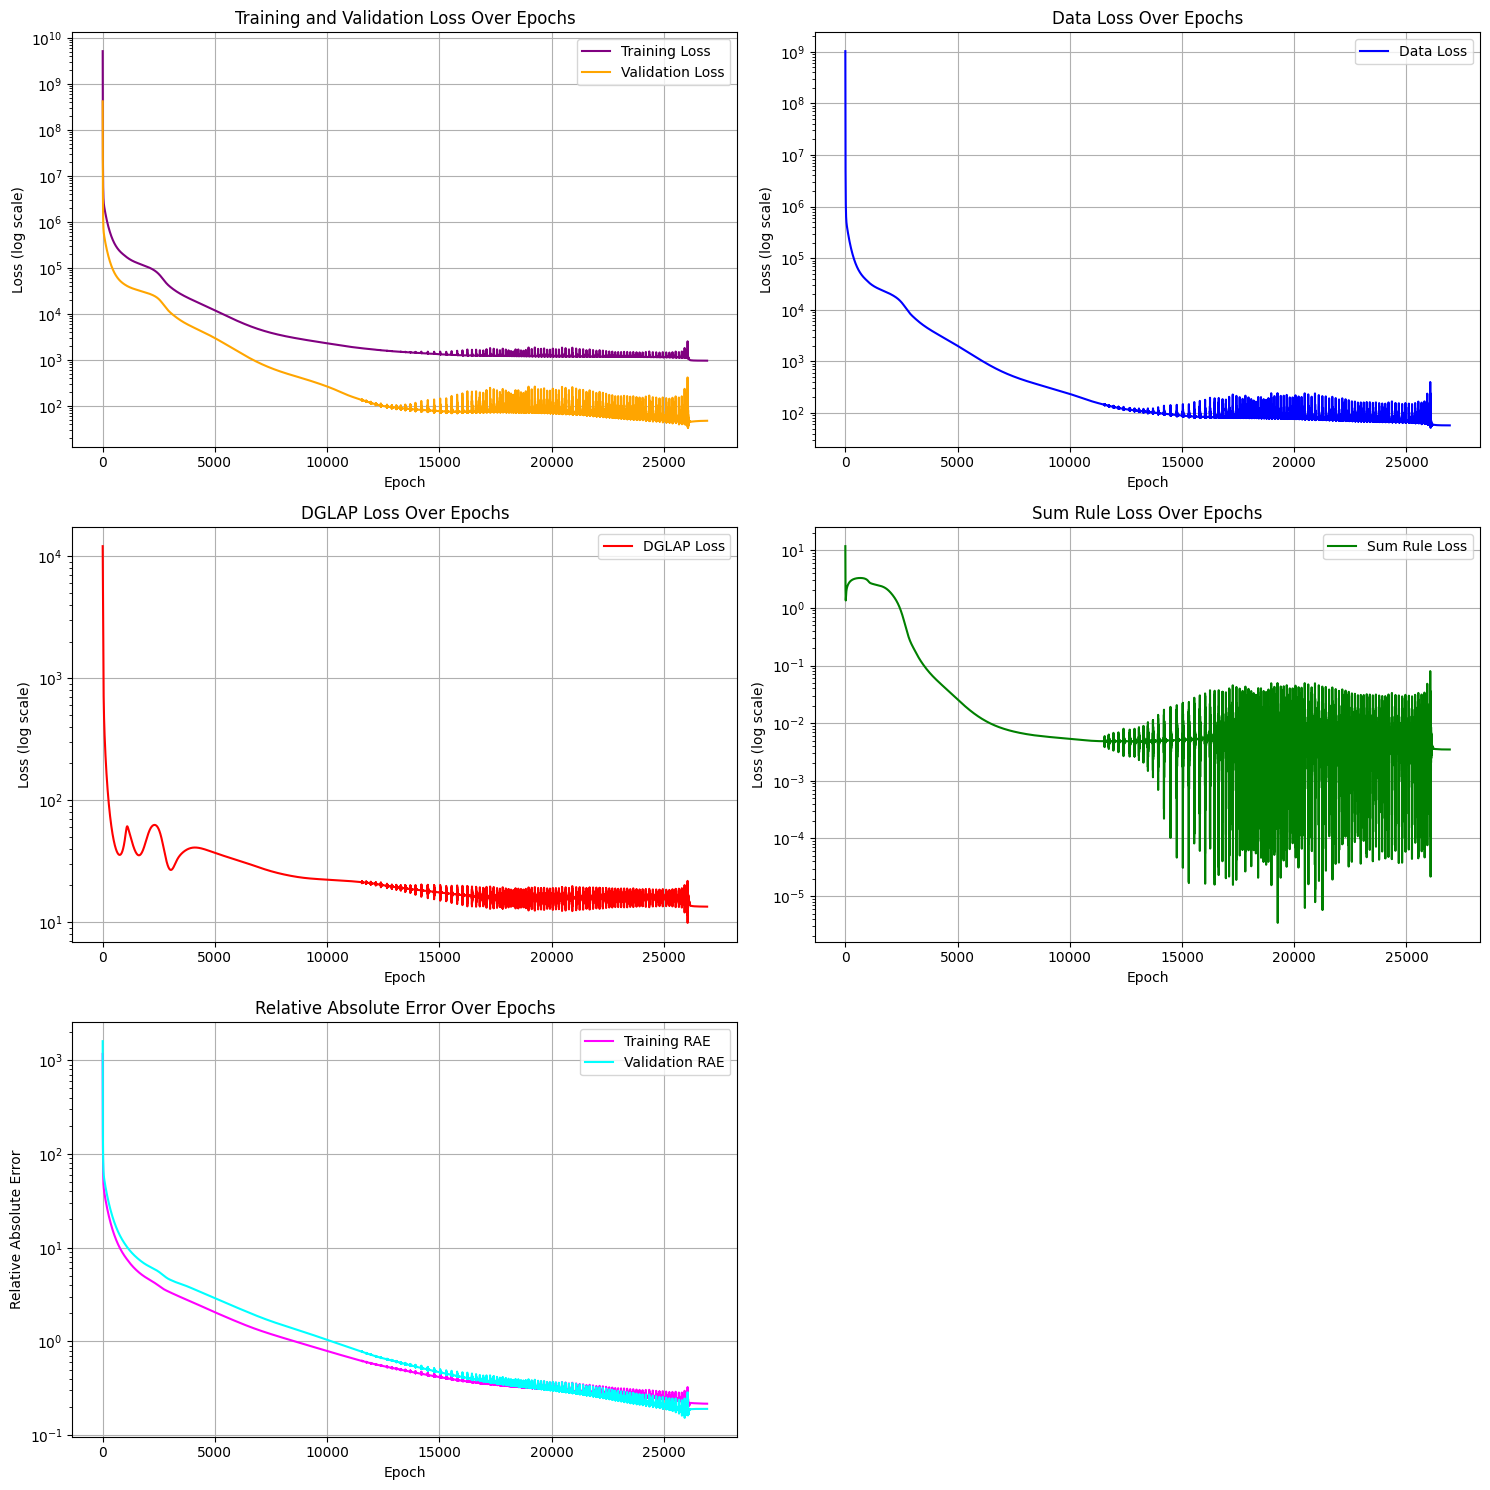

In [ ]:
fig, axes_2d = plt.subplots(3, 2, figsize=(15, 15)) # Changed to 3 rows, 2 columns to accommodate new plot
axes = axes_2d.flatten() # Flatten the axes array to ensure 1D access

# Plot Training and Validation Loss
axes[0].plot(train_losses, label='Training Loss', color='purple')
axes[0].plot(val_losses, label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale('log')

# Plot Data Loss (Now at [0, 1])
axes[1].plot(data_losses_log, label='Data Loss', color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Data Loss Over Epochs')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')

# Plot Physics Loss
axes[2].plot(phys_losses_log, label='DGLAP Loss', color='red') # Changed label for clarity
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (log scale)')
axes[2].set_title('DGLAP Loss Over Epochs') # Changed title for clarity
axes[2].legend()
axes[2].grid(True)
axes[2].set_yscale('log')

# Plot Sum Rule Loss
axes[3].plot(sr_losses_log, label='Sum Rule Loss', color='green') # New subplot
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Loss (log scale)')
axes[3].set_title('Sum Rule Loss Over Epochs')
axes[3].legend()
axes[3].grid(True)
axes[3].set_yscale('log')

# Plot Relative Absolute Error
axes[4].plot(train_rae_log, label='Training RAE', color='magenta')
axes[4].plot(val_rae_log, label='Validation RAE', color='cyan')
axes[4].set_xlabel('Epoch')
axes[4].set_ylabel('Relative Absolute Error')
axes[4].set_title('Relative Absolute Error Over Epochs')
axes[4].legend()
axes[4].grid(True)
axes[4].set_yscale('log')

# Hide the unused 6th subplot if there are only 5 plots
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

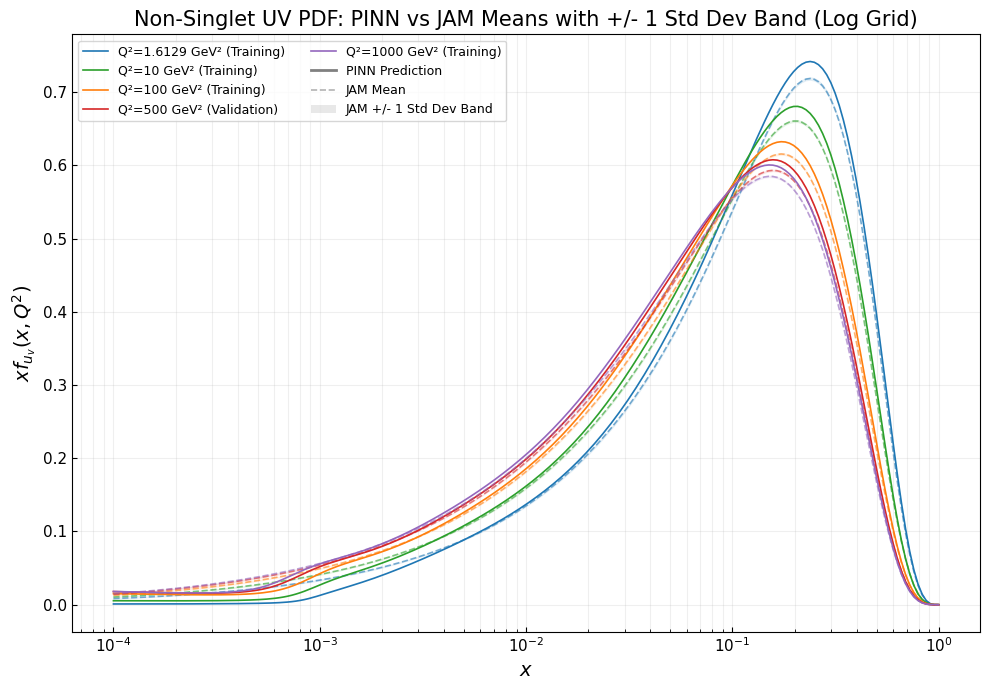

In [ ]:

model.eval()
log_x_np = np.log(X)

# Define colors for each Q2 scale
colors = {
    1.6129: '#1f77b4',   # blue
    10:     '#2ca02c',   # green
    100:    '#ff7f0e',   # orange
    500:    '#d62728',   # crimson
    1000:   '#9467bd',   # purple
}

fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    color = colors.get(q2, 'black')

    label_suffix = ''
    if q2 == VAL_Q2:
        label_suffix = ' (Validation)'
    else:
        label_suffix = ' (Training)'

    # 1. JAM +/- 1 Std Dev band (interpolated in cell 3)
    lo     = treypdf_log[q2]['uv_lo']
    hi     = treypdf_log[q2]['uv_hi']
    mean   = treypdf_log[q2]['uv']
    ax.fill_between(X, lo, hi, color=color, alpha=0.12, linewidth=0)
    ax.plot(X, mean, color=color, lw=1.2, ls='--', alpha=0.6)

    # 2. Network prediction
    x_np      = X # Prepare X values for input
    log_q2_np = np.full(N_x, np.log(q2))
    inp_np = np.stack([x_np, log_x_np, log_q2_np], axis=1) # Stack X, ln(X), and ln(Q^2) as input features for prediction
    inp_t  = torch.tensor(inp_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()

    ax.plot(X, pred, color=color, lw=1.2, label=f'Q²={q2} GeV²{label_suffix}')

line_nn  = plt.Line2D([0], [0], color='grey', lw=2,
                       label='PINN Prediction')
line_med = plt.Line2D([0], [0], color='grey', lw=1.2, ls='--', alpha=0.6,
                       label='JAM Mean')
line_band = plt.matplotlib.patches.Patch(facecolor='grey', alpha=0.18,
                       label='JAM +/- 1 Std Dev Band')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [line_nn, line_med, line_band],
          fontsize=9, loc='upper left', ncol=2)

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('Non-Singlet UV PDF: PINN vs JAM Means with +/- 1 Std Dev Band (Log Grid)', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)

plt.tight_layout()
plt.show()

## Examine the Prediction's Coverage of JAM Data

In [ ]:
# Coverage check
# +/- 1 Std Dev bands were already interpolated onto the log grid X in
# cell 3 (treypdf_log[q2]['uv_lo'] and 'uv_hi'). We use those directly
# here, avoiding redundant CubicSpline construction per Q2.

model.eval()
log_x_np = np.log(X)

print('Coverage within +/- 1 Std Dev JAM replica band:')
print(f'{"Q2 (GeV2)":>12} | {"Coverage":>10} | {"Set Type":>10}')
print('-' * 42)

for q2 in Q2_vals:
    # 1. Use pre-interpolated bands from cell 3
    lower = treypdf_log[q2]['uv_lo']
    upper = treypdf_log[q2]['uv_hi']

    # 2. Network prediction on X
    x_np      = X # Prepare X values for input
    log_q2_np = np.full(N_x, np.log(q2))
    inp_np    = np.stack([x_np, log_x_np, log_q2_np], axis=1) # Stack X, ln(X), and ln(Q^2) as input features for prediction
    inp_t     = torch.tensor(inp_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()

    # 3. Coverage: fraction of x points where prediction is inside band
    inside   = (pred >= lower) & (pred <= upper)
    coverage = np.mean(inside) * 100
    set_type = 'Validation' if q2 == VAL_Q2 else 'Training'

    print(f'{q2:>12g} | {coverage:>9.1f}% | {set_type:>10}')

Coverage within +/- 1 Std Dev JAM replica band:
   Q2 (GeV2) |   Coverage |   Set Type
------------------------------------------
      1.6129 |       4.0% |   Training
          10 |       7.0% |   Training
         100 |       8.5% |   Training
         500 |      15.5% | Validation
        1000 |      16.0% |   Training


The low percent coverage is likely due to the narrowness of the +/- one standard deviation bands. Previously, we used 95% bands to check for coverage (+/- 2 StD from mean if a Gaussian distribution), so this coverage check may not be the best metric to understand the accuracy of the PINN's prediction, rather it checks the precision of the prediction.

In [ ]:
save_path = '/content/drive/MyDrive/v6_pinn_uv_model.pt'
torch.save({
    'model_state_dict' : model.state_dict(),
    'best_val_loss'    : best_val_loss,
    'Q2_vals'          : Q2_vals,
    'val_Q2'           : VAL_Q2,
    'lambda_dglap'     : LAMBDA_DGLAP,
    'alpha_s'          : 'running LO',
    'train_losses'     : train_losses,
    'val_losses'       : val_losses,
    'phys_losses'      : phys_losses_log,
    'sr_losses'        : sr_losses_log,
    'train_rae_log'    : train_rae_log,
    'val_rae_log'      : val_rae_log,
    'best_val_rae'     : best_val_rae,
    # FIX (issue 8): corrected — alpha_s is running LO, not fixed at 0.1
'notes'            : 'PINN v5 — DGLAP non-singlet, running alpha_s LO, Simpson rule, chi-square data loss, RAE early stopping'
}, save_path)
print(f'Saved to {save_path}')

Saved to /content/drive/MyDrive/v6_pinn_uv_model.pt


# Predict PDFs at Extended Q^2



The data file has been updated to include data on a fully log-spaced grid: no interpolation needed.

Various Q^2 levels have been added to assess the model's predictive ability. Ask the model to predict PDFs at a given X as a function of Q^2.

In [ ]:
# ── 0. Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/colab_notebooks/trey24_no_sidis_lo_extended.zip'

# FIX (issue 6): use _ext suffix so these variables do not overwrite the
# training-loop globals treypdf, X, log_x, N_x. If cell 36 were re-run
# after cell 50 with the old names, it would silently use the wrong data.
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf_ext = np.load(f, allow_pickle=True).item()

X_ext     = 10**np.linspace(-4, np.log10(1), 200)
log_x_ext = np.log(X_ext)
N_x_ext   = 200

print('Extended Q² values:')
print(treypdf_ext.keys())

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extended Q² values:
dict_keys([1.6129, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000])


### Load the Saved Model for Prediction

To use your trained model, you'll first need to ensure the `PINN` class (defined earlier in this notebook) is available in your environment. Then, load the `model_state_dict` from your saved checkpoint. After loading, set the model to evaluation mode (`model.eval()`) for prediction.

Once the model is loaded, you can define an array of `Q2_EXTENDED_VALS` (e.g., from your updated data file or any arbitrary new Q² values) for which you want to generate predictions. For each `Q²` value, you'll create an input tensor similar to how `train_X` and `val_X` were constructed, stacking `x`, `ln(x)`, and `ln(Q²)`. Finally, pass this input to the model to get the PDF predictions.

In [ ]:
# ── 2. Instantiate and Load the Model ────────────────────────────────────
# Ensure the PINN class is defined and run before this cell
model = PINN().to(device)

CHECKPOINT_PATH = '/content/drive/MyDrive/v6_pinn_uv_model.pt'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set model to evaluation mode for inference
print(f'Model loaded from: {CHECKPOINT_PATH}')

# ── 3. Define New Q² Values for Prediction (Example) ───────────────────────
Q2_EXTENDED_VALS = [1.6129, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000]

# ── 4. Generate Predictions for Extended Q² Values ───────────────────────
predictions_extended_q2 = {}

print('\nGenerating predictions for extended Q² values:')
for q2 in Q2_EXTENDED_VALS:
    log_q2_np = np.full(N_x_ext, np.log(q2))  # FIX (issue 6): use N_x_ext
    # Stack X_ext, ln(X_ext), and ln(Q^2) as input features
    inp_np = np.stack([X_ext, log_x_ext, log_q2_np], axis=1)  # FIX (issue 6)
    inp_t  = torch.tensor(inp_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()

    predictions_extended_q2[q2] = pred
    print(f'  Generated prediction for Q² = {q2} GeV²')


Model loaded from: /content/drive/MyDrive/v6_pinn_uv_model.pt

Generating predictions for extended Q² values:
  Generated prediction for Q² = 1.6129 GeV²
  Generated prediction for Q² = 10 GeV²
  Generated prediction for Q² = 15 GeV²
  Generated prediction for Q² = 20 GeV²
  Generated prediction for Q² = 30 GeV²
  Generated prediction for Q² = 40 GeV²
  Generated prediction for Q² = 50 GeV²
  Generated prediction for Q² = 60 GeV²
  Generated prediction for Q² = 70 GeV²
  Generated prediction for Q² = 80 GeV²
  Generated prediction for Q² = 90 GeV²
  Generated prediction for Q² = 100 GeV²
  Generated prediction for Q² = 200 GeV²
  Generated prediction for Q² = 300 GeV²
  Generated prediction for Q² = 400 GeV²
  Generated prediction for Q² = 500 GeV²
  Generated prediction for Q² = 600 GeV²
  Generated prediction for Q² = 700 GeV²
  Generated prediction for Q² = 800 GeV²
  Generated prediction for Q² = 900 GeV²
  Generated prediction for Q² = 1000 GeV²
  Generated prediction for Q² = 200

Now plot predictions at a given X as a function of Q^2.

Selected x for Q² evolution (subplot 1): 0.0010 (closest to 0.001)
Selected x for Q² evolution (subplot 2): 0.0196 (closest to 0.02)
Selected x for Q² evolution (subplot 3): 0.0988 (closest to 0.1)
Selected x for Q² evolution (subplot 4): 0.6906 (closest to 0.7)


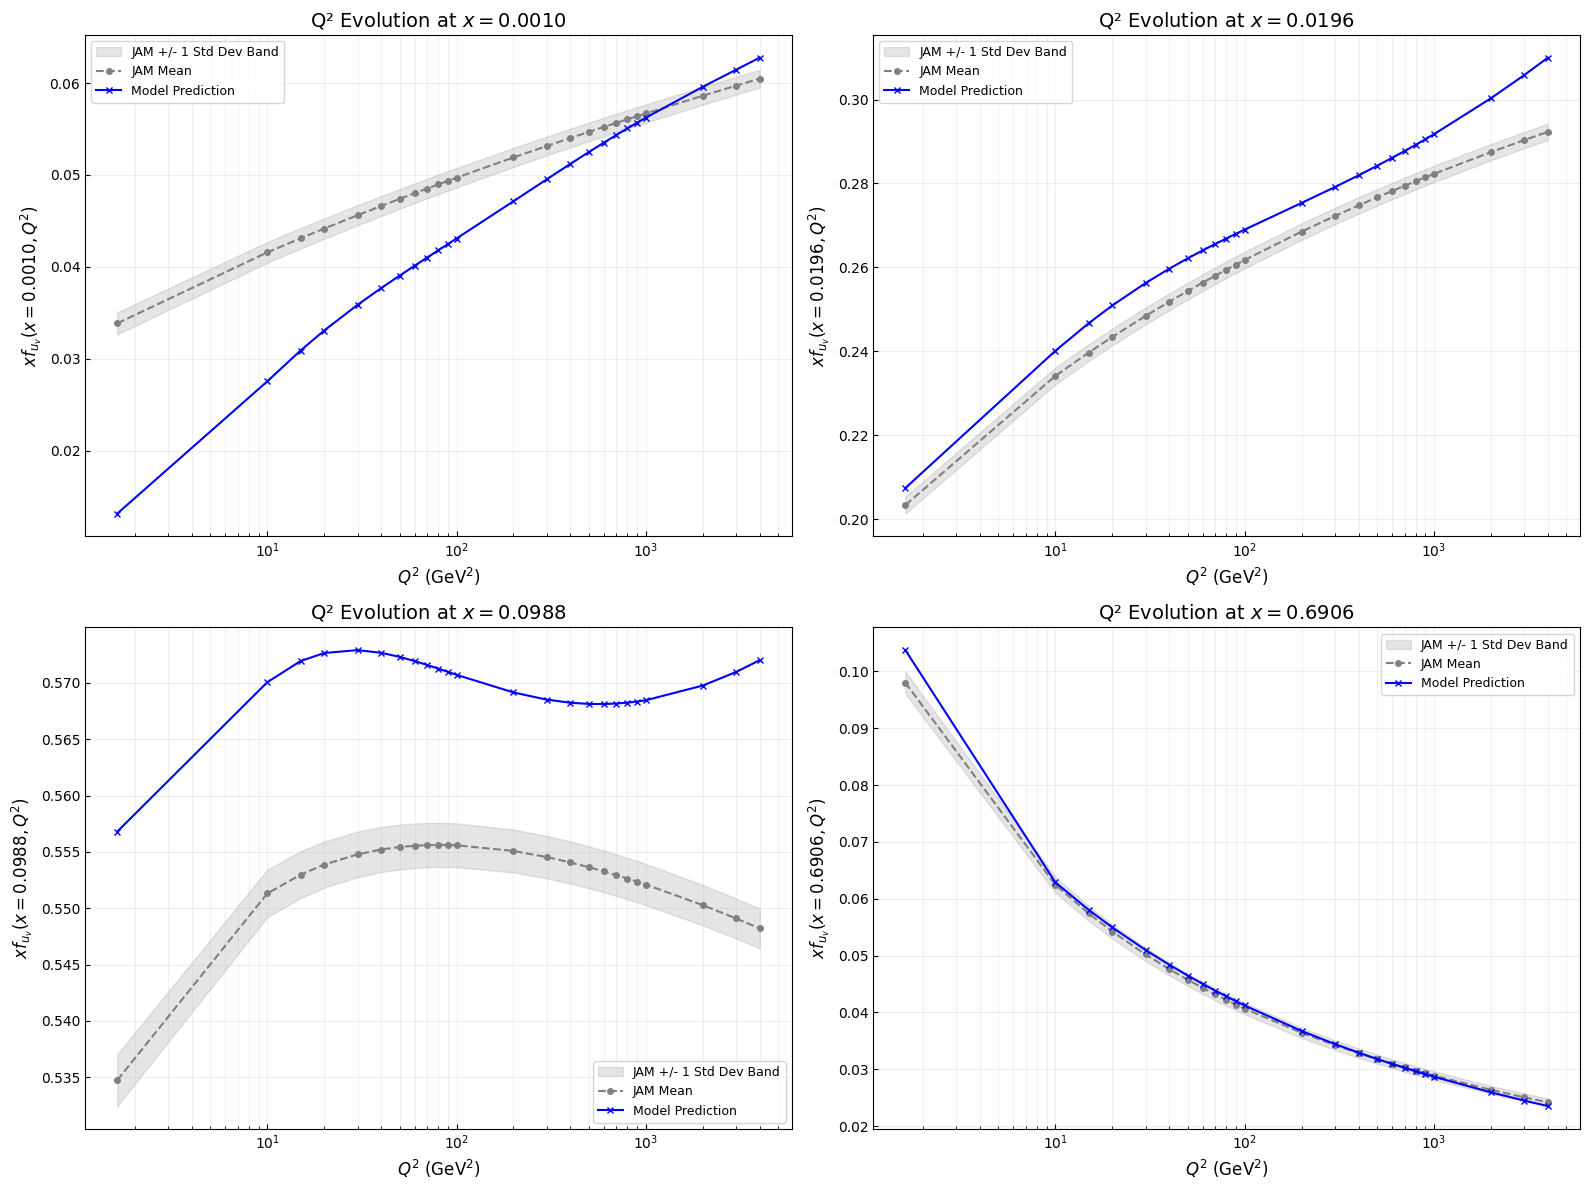

In [ ]:

# Choose the fixed x values to plot
FIXED_X_VALS = [1e-3, 0.02, 0.1, 0.7]

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2 rows, 2 columns
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, fixed_x in enumerate(FIXED_X_VALS):
    ax = axes[i] # Get the current subplot axis

    # Find the index of the closest x value in the X array
    x_idx = (np.abs(X_ext - fixed_x)).argmin()  # FIX (issue 6): use X_ext
    actual_x_val = X_ext[x_idx]  # FIX (issue 6): use X_ext
    print(f"Selected x for Q² evolution (subplot {i+1}): {actual_x_val:.4f} (closest to {fixed_x})")

    # Prepare lists to store data for the DataFrame for the current x-value
    q2_values_plot = []
    model_predictions_at_x = []
    jam_mean_at_x = []
    jam_lo_at_x = []
    jam_hi_at_x = []

    for q2 in sorted(Q2_EXTENDED_VALS):
        q2_values_plot.append(q2)

        # Get model prediction at the fixed x_idx
        model_predictions_at_x.append(predictions_extended_q2[q2][x_idx])

        # Get JAM data if available for this Q²
        if q2 in treypdf_ext:  # FIX (issue 6): use treypdf_ext
            uv_reps = treypdf_ext[q2]['uv']
            uv_mean = np.mean(uv_reps, axis=0)
            uv_std  = np.std(uv_reps, axis=0)
            uv_lo   = uv_mean - uv_std
            uv_hi   = uv_mean + uv_std

            jam_mean_at_x.append(uv_mean[x_idx])
            jam_lo_at_x.append(uv_lo[x_idx])
            jam_hi_at_x.append(uv_hi[x_idx])
        else:
            jam_mean_at_x.append(np.nan) # Use NaN if no JAM data for this Q²
            jam_lo_at_x.append(np.nan)
            jam_hi_at_x.append(np.nan)

    # Create a DataFrame for the current x-value
    df_q2_evolution_current_x = pd.DataFrame({
        'Q2': q2_values_plot,
        'Model_Prediction': model_predictions_at_x,
        'JAM_Mean': jam_mean_at_x,
        'JAM_Lo': jam_lo_at_x,
        'JAM_Hi': jam_hi_at_x
    })

    # Plot JAM bands and means (where available) for the current x-value
    ajam_data_present = df_q2_evolution_current_x.dropna(subset=['JAM_Mean'])
    ax.fill_between(
        ajam_data_present['Q2'],
        ajam_data_present['JAM_Lo'],
        ajam_data_present['JAM_Hi'],
        color='grey', alpha=0.2, label='JAM +/- 1 Std Dev Band'
    )
    ax.plot(
        ajam_data_present['Q2'],
        ajam_data_present['JAM_Mean'],
        color='grey', linestyle='--', marker='o', markersize=4, label='JAM Mean'
    )

    # Plot Model Predictions for the current x-value
    ax.plot(
        df_q2_evolution_current_x['Q2'],
        df_q2_evolution_current_x['Model_Prediction'],
        color='blue', linestyle='-', marker='x', markersize=4, label='Model Prediction'
    )

    ax.set_xscale('log')
    ax.set_xlabel(r'$Q^2$ (GeV$^2$)', size=12)
    ax.set_ylabel(r'$xf_{{u_v}}(x={:.4f}, Q^2)$'.format(actual_x_val), size=12)
    ax.set_title(f'Q² Evolution at $x={actual_x_val:.4f}$', size=14)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.tick_params(direction='in', which='both', labelsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Evaluate Choice of the number of GL Nodes

We want to maximize both accuracy and efficiency of the PINN training. Since the current number of GL nodes was chosen arbitrarily, we should perform convergence testing to see if we can decrease the number of nodes without sacrificing accuracy.

We will use the pre-trained model to predict $f_{uv}(X, Q^2)$ at $x = 1e^-3, 0.05, 0.25, 0.7$ at both $Q^2 = 1.6129$. Since the PDF is most sharply peaked at $Q^2 = 1.6129$, it will require the highest degree polynomial to approximate it, giving the highest needed number of nodes for accurate integration.

The number of nodes tested will be $N=8, 16, 32, 64, 128$.

In [ ]:
# Ensure the PINN class is defined and run before this cell
model = PINN().to(device)

CHECKPOINT_PATH = '/content/drive/MyDrive/v6_pinn_uv_model.pt'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set model to evaluation mode for inference
print(f'Model loaded from: {CHECKPOINT_PATH}')

Model loaded from: /content/drive/MyDrive/v6_pinn_uv_model.pt


In [ ]:

test_x_vals = [1e-3, 0.05, 0.25, 0.7]
N_vals = [8, 16, 32, 64, 128]
results = {}

model.eval()
with torch.no_grad():
    for N in N_vals:
        nodes_np, weights_np = leggauss(N)
        nodes   = torch.tensor(nodes_np,   dtype=torch.float32, device=device)
        weights = torch.tensor(weights_np, dtype=torch.float32, device=device)

        # use your existing xf_fn construction for Q2=1.6129
        xf_fn = make_xf_fn(model, 1.6129, device)

        # evaluate convolution at each test x
        x_test_t = torch.tensor(test_x_vals, dtype=torch.float32, device=device)
        rhs = dglap_convolution_gl(xf_fn, x_test_t, nodes, weights, alphas_Q2[1.6129])
        results[N] = rhs.cpu().numpy()

# Print convergence table
print(f"{'N':>6} | {'x=1e-3':>12} | {'x=0.05':>12} | {'x=0.25':>12} | {'x=0.7':>12}")
for N in N_vals:
    vals = results[N]
    print(f"{N:>6} | {vals[0]:>12.8f} | {vals[1]:>12.8f} | {vals[2]:>12.8f} | {vals[3]:>12.8f}")

     N |       x=1e-3 |       x=0.05 |       x=0.25 |        x=0.7
     8 |   7.81650114 |   1.24290490 |   0.05618229 |  -0.03442900
    16 |   7.80867147 |   1.24288177 |   0.05618404 |  -0.03442902
    32 |   7.80866432 |   1.24288130 |   0.05618382 |  -0.03442909
    64 |   7.80866957 |   1.24288082 |   0.05618419 |  -0.03442912
   128 |   7.80865526 |   1.24288166 |   0.05618436 |  -0.03442914


In [ ]:
import numpy as np

N_COL_WIDTH = 6
X_VAL_COL_WIDTH = 12
DIFF_VAL_WIDTH = 13 # for X.XXXX

# Determine the total width of the percentage columns for header alignment
# The format string " | XXXXXXXXXXXXX% XXXXXXXXXXXXX% XXXXXXXXXXXXX% XXXXXXXXXXXXX%"
# has 1 for " |", 4 * (DIFF_VAL_WIDTH + 1 for '%') + 3 for spaces = 4 * 14 + 3 = 59
PERCENT_COL_DISPLAY_WIDTH = (DIFF_VAL_WIDTH + 1) * 4 + 3

print(
    f"\n{'N':>{N_COL_WIDTH}} | "
    f"{'x=1e-3':>{X_VAL_COL_WIDTH}} | "
    f"{'x=0.05':>{X_VAL_COL_WIDTH}} | "
    f"{'x=0.25':>{X_VAL_COL_WIDTH}} | "
    f"{'x=0.7':>{X_VAL_COL_WIDTH}} | "
    f"{'% Diff (Prev N)':>{PERCENT_COL_DISPLAY_WIDTH}}"
)

# Adjust separator length dynamically
total_line_length = (N_COL_WIDTH + 3 # N + ' | '
                     + (X_VAL_COL_WIDTH + 3) * 4 - 3 # 4 x-columns, each with ' | ' except last
                     + (PERCENT_COL_DISPLAY_WIDTH + 3) - 3) # 1 percent column
print('-' * total_line_length)

prev_vals = None
for N in N_vals:
    vals = results[N]
    diff_str = ''
    if prev_vals is not None:
        percent_diff = np.abs((vals - prev_vals) / ((vals + prev_vals) / 2)) * 100
        diff_str = (f" | {percent_diff[0]:>{DIFF_VAL_WIDTH}.4f}% "
                    f"{percent_diff[1]:>{DIFF_VAL_WIDTH}.4f}% "
                    f"{percent_diff[2]:>{DIFF_VAL_WIDTH}.4f}% "
                    f"{percent_diff[3]:>{DIFF_VAL_WIDTH}.4f}%")
    else:
        # If no previous values, fill with spaces to maintain column width for Prev N
        # The ' | ' prefix is part of diff_str, so calculate total needed spaces
        diff_str = f" | {'':>{PERCENT_COL_DISPLAY_WIDTH}}"


    print(f"{N:>{N_COL_WIDTH}} | "
          f"{vals[0]:>{X_VAL_COL_WIDTH}.8f} | "
          f"{vals[1]:>{X_VAL_COL_WIDTH}.8f} | "
          f"{vals[2]:>{X_VAL_COL_WIDTH}.8f} | "
          f"{vals[3]:>{X_VAL_COL_WIDTH}.8f}"
          f"{diff_str}")
    prev_vals = vals


     N |       x=1e-3 |       x=0.05 |       x=0.25 |        x=0.7 |                                             % Diff (Prev N)
-----------------------------------------------------------------------------------------------------------------------------
     8 |   7.81650114 |   1.24290490 |   0.05618229 |  -0.03442900 |                                                            
    16 |   7.80867147 |   1.24288177 |   0.05618404 |  -0.03442902 |        0.1002%        0.0019%        0.0031%        0.0001%
    32 |   7.80866432 |   1.24288130 |   0.05618382 |  -0.03442909 |        0.0001%        0.0000%        0.0004%        0.0002%
    64 |   7.80866957 |   1.24288082 |   0.05618419 |  -0.03442912 |        0.0001%        0.0000%        0.0007%        0.0001%
   128 |   7.80865526 |   1.24288166 |   0.05618436 |  -0.03442914 |        0.0002%        0.0001%        0.0003%        0.0001%
